/var/folders/06/88893yxd5qg_yw5z0dncmm4r0000gp/T/ipykernel_16557/2517933285.py:119: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


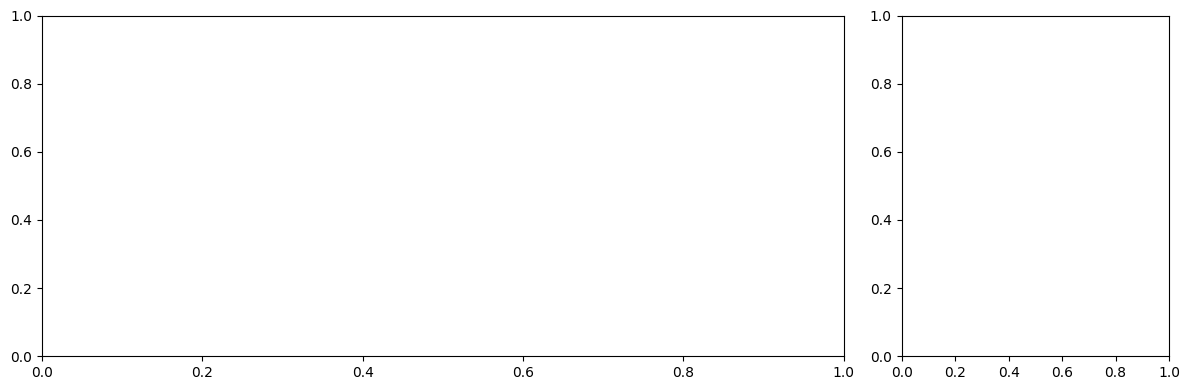

In [91]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

T = 100
n_min = 10
H = 10
N = 6
n_bootstrap = 30

t = np.linspace(0, 2, T+H)
y_hat = np.cos(np.pi * t * N) + 0.5 * t
y = y_hat + 0.3 * np.random.randn(len(t)) + (np.random.rand(len(t)) > 0.95) * np.random.randn(len(t))*1.2

fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [3, 1]}, layout='constrained'
)

n_backtest = T - n_min - H
n_frames = n_backtest + n_bootstrap

residuals = np.zeros((n_backtest, H))
rnd_idxs = np.random.randint(0, n_backtest, size=n_bootstrap)

def update(i):
    ax[0].clear()
    ax[1].clear()

    ax[0].plot(t, y, linestyle='none')

    if i < n_backtest:
        ax[0].plot(
            t[:i+n_min+H],
            y[:i+n_min+H],
            label='observations',
            alpha=0.5
        )

        ax[0].plot(
            t[i+n_min:i+n_min+H],
            y_hat[i+n_min:i+n_min+H],
            linestyle='dashed',
            linewidth=2,
            label='forecast'
        )

        current_residual = y[i+n_min:i+n_min+H] - y_hat[i+n_min:i+n_min+H]
        residuals[i, :] = current_residual
        ax[1].matshow(residuals, aspect='auto', cmap='viridis')
        n_rows, n_cols = residuals.shape
        ax[1].set_xlim(-0.5, n_cols + 0.5)
        ax[0].text(
            0.5, np.max(y),
            f"Retrieve errors on training, step: {i+1}/{n_backtest}",)
    else:
        b = i - n_backtest

        ax[0].plot(
            t[:T],
            y[:T],
            label='observations',
            alpha=0.5
        )

        ax[0].plot(
            t[T:T+H],
            y_hat[T:T+H],
            linestyle='dashed',
            linewidth=2,
            label='forecast'
        )

        for j in range(b + 1):
            ax[0].plot(
                t[T:T+H],
                y_hat[T:T+H] + residuals[rnd_idxs[j], :],
                linewidth=0.3,
                color='red',
                alpha=0.9
            )
        row_idx = rnd_idxs[b]
        ax[1].matshow(residuals, aspect='auto', cmap='viridis')
        n_rows, n_cols = residuals.shape
        ax[1].set_xlim(-0.5, n_cols + 0.5)

        ax[1].plot(
            [n_cols, n_cols],
            [row_idx - 0.5, row_idx + 0.5],
            color='red',
            linewidth=10,
            solid_capstyle='butt'
        )
        #ax[1].matshow(residuals, aspect='auto', cmap='viridis')
        ax[0].text(
        0.5, np.max(y),
        f"Bootstrap errors at testing, sample: {b}/{n_bootstrap}",)

    ax[0].spines[['top', 'right']].set_visible(False)
    ax[0].legend()
    ax[0].set_ylim(np.min(y), np.max(y)*1.4)

    ax[1].xaxis.set_ticks_position('bottom')
    ax[1].xaxis.set_label_position('bottom')

    ax[1].spines[['top', 'right']].set_visible(False)

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=100,
    repeat=False
)

plt.tight_layout()
plt.show()

In [92]:
ani.save("bootstrap_animation.gif", writer="pillow", fps=5)
